### Import libraries

In [ ]:
import os
import pickle
from syto.deconvolution.xgbdeconvolver import *
from tqdm import tqdm
from collections import defaultdict
import torch.nn as nn
from copy import deepcopy
from syto.deconvolution.deep_deconvolvers.training import train_matrix_deconvolver
import os.path as Path
from torch.utils.data import DataLoader, TensorDataset
from syto.deconvolution.least_squares_deconvolvers import (
    NNLSDeconvolver,
    PSLSDeconvolver,
)
from syto.deconvolution.evaluation import compute_deconvolution_metrics
from syto.calibration.linear_calibrator import LinearCalibrator
from syto.deconvolution.deep_deconvolvers.mlp import MLPDeconvolver
from syto.deconvolution.deep_deconvolvers.swn import SWNDeconvolver 

### Configuring target model and extracting computed average scores

In [57]:
from edautils import *

reads_data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/SoftLabelsForRRBSsplits_205files_pooled_Jaccard_hg38_mincpg_4_minlen_10_d041/"
grg_label_column = "dmr_ctype_label"
mincpg_pointer = reads_data_path.find("mincpg_")
# classifier_model_path = f"../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_{grg_label_column}_{reads_data_path[mincpg_pointer:]}"
classifier_model_path = "/mnt/data/syto_experiments/mlflow/198121009408531961/1f0aaa3947bb4732a945e76aed3a5864/artifacts/deconvolution/top_156_features/"
mincpg = int(reads_data_path[mincpg_pointer + 7 : mincpg_pointer + 8])
features_encoding = "extracted_numpy"
n_cell_types = num_dmr_groups = 39
n_pred_classes = 39 if "soft_labels" in classifier_model_path else 40

In [58]:
features_file = [
    x for x in os.listdir(classifier_model_path) if "features_cutoff" in x
][0]

In [59]:
df = np.load(Path.join(classifier_model_path, features_file))

In [60]:
# features_test = df["features_test"]
features_train = df["features_train"]
features_valid = df["features_valid"]
features_test = df["features_test"]
target_proportions_train = df["proportions_train"]
target_proportions_valid = df["proportions_valid"]
target_proportions_test = df["proportions_test"]

### Defining deconvolvers

In [61]:
n_features = len(features_train[0])

In [62]:
nnls = NNLSDeconvolver()
psls = PSLSDeconvolver()

### Loading deconvolvers weights

In [63]:
device = "cuda"

In [64]:
mlp = MLPDeconvolver.load(path=Path.join(classifier_model_path, "mlp_best_deconvolver.pt"), metadata_path=Path.join(classifier_model_path, "mlp_architecture_meta.json"))
swn = SWNDeconvolver.load(path=Path.join(classifier_model_path, "swn_best_deconvolver.pt"), metadata_path=Path.join(classifier_model_path, "swn_architecture_meta.json"))
xgb = XGBoostDeconvolver.load(Path.join(classifier_model_path, "xgb_deconvolver.joblib"))
nnls = nnls.load(Path.join(classifier_model_path, "nnls_deconvolver.joblib"))
psls = psls.load(Path.join(classifier_model_path, "psls_deconvolver.joblib"))

/usr/lib/python3.12/pickle.py:1760: UserWarning: [11:43:53] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/syto-_TU1nSN1-py3.12/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.7.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability

### Generating predictions

In [65]:
results = defaultdict(tuple)
model_tripples = [
    (swn, "swn", "nn"),
    (mlp, "mlp", "nn"),
    (xgb, "xgb", "xgb"),
    (nnls, "nnls", "ls"),
    (psls, "psls", "ls"),
]

In [66]:
def infer_multiple_deconvolvers(features, target_proportions, model_tripples):
    test_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(features), torch.FloatTensor(target_proportions)
        ),
        batch_size=2000,
    )
    results = defaultdict(tuple)
    for model, model_name, model_type in model_tripples:
        all_preds = []
        all_targets = target_proportions
        if model_type == "nn":
            all_targets = []
            with torch.no_grad():
                for X, y in test_loader:
                    # X, y = X.to(device), y.to(device)
                    pred = model.predict(X)
                    all_preds.append(pred)
                    all_targets.append(y)
            # Compute all metrics
            all_preds = np.concat(all_preds, axis=0)
            all_targets = np.concat(all_targets, axis=0)
        elif model_type == "xgb":
            all_preds = model._predict_raw(features)
            all_preds = model._transform_output(all_preds)
        elif model_type == "ls":
            if "nnls" in model_name:
                all_preds = model.predict(features, n_workers=1)
            elif "psls" in model_name:
                all_preds = model.predict(features, n_workers=2)
        else:
            pass
        metrics = compute_deconvolution_metrics(all_preds, all_targets)
        all_preds = np.round(all_preds, 4)

        results[model_name] = (all_targets, all_preds, metrics)

    return results

In [67]:
results_test = infer_multiple_deconvolvers(
    features=features_test,
    target_proportions=target_proportions_test,
    model_tripples=model_tripples,
)

Predicting with PSLS in parallel: 100%|██████████| 1000/1000 [02:25<00:00,  6.90it/s]


In [68]:
from edautils import plot_deconvolution_results   

In [69]:
results_test.keys()

dict_keys(['swn', 'mlp', 'xgb', 'nnls', 'psls'])

In [70]:
import json
labels_dict_path = "/home/luna.kuleuven.be/u0169940/Repos/syto/App/labels_dict.json"
with open(labels_dict_path, "r", encoding="utf-8") as f:
            # JSON keys are strings; convert to {int: str}
            labels_dict = json.load(f)

In [72]:
keys = labels_dict.keys()
for key in keys:
    labels_dict[int(key)] = labels_dict.pop(key)

(<Figure size 2000x1000 with 2 Axes>,
 {'celltype_metrics': {'overall_r2': 0.9831522703170776,
   'per_celltype_r2': {'Adipocytes': 0.982833981513977,
    'Bladder-Ep': 0.9805876016616821,
    'Blood-B': 0.9626935720443726,
    'Blood-Granul': 0.9970414638519287,
    'Blood-Mono+Macro': 0.9922277927398682,
    'Blood-NK': 0.9964792728424072,
    'Blood-T': 0.9900214672088623,
    'Bone-Osteob': 0.9968034029006958,
    'Breast-Basal-Ep': 0.9843273162841797,
    'Breast-Luminal-Ep': 0.9950091242790222,
    'Colon-Ep': 0.9971425533294678,
    'Colon-Fibro': 0.8423721194267273,
    'Dermal-Fibro': 0.9745991230010986,
    'Endothel': 0.9543002843856812,
    'Epid-Kerat': 0.9947177171707153,
    'Eryth-prog': 0.9966893792152405,
    'Fallopian-Ep': 0.970394492149353,
    'Gallbladder': 0.977540910243988,
    'Gastric-Ep': 0.997646152973175,
    'Head-Neck-Ep': 0.9965903162956238,
    'Heart-Cardio': 0.9976819753646851,
    'Heart-Fibro': 0.9951790571212769,
    'Kidney-Ep': 0.995516955852508

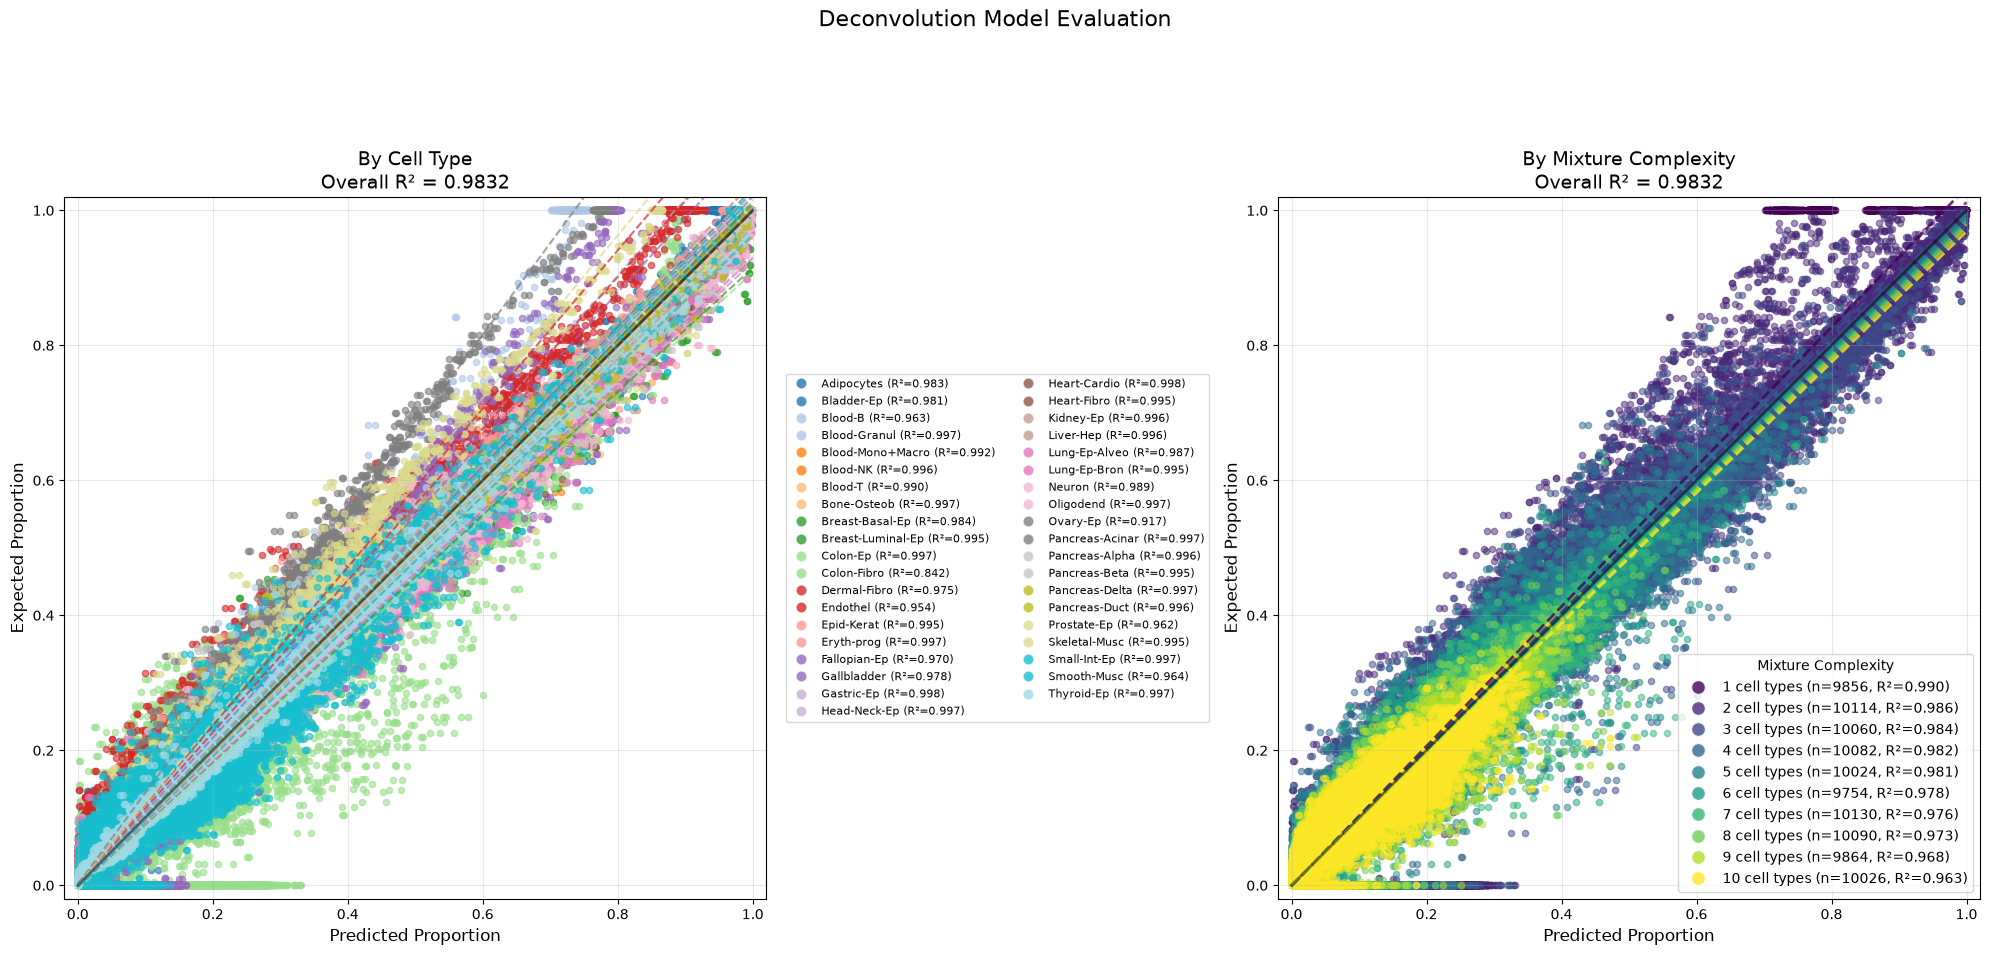

In [73]:
plot_deconvolution_results(results_test["swn"][0], results_test["swn"][1], labels_dict=labels_dict)

In [14]:
import pandas as pd


def results_to_dataframe(results: dict, class_names: list = None) -> pd.DataFrame:
    """
    Convert the results dict into a DataFrame matching the supplementary table columns.

    Expected results structure:
        results[model_name] = (all_targets, all_preds, metrics_dict)

    model_name convention assumed (adjust parsing as needed):
        e.g. "hard_rej__dsimir__dirichlet__xgb__linear"
              labeling__classifier__clf_calib__deconvolver__dec_calib
    """
    rows = []
    for model_name, (targets, preds, metrics) in results.items():
        # --- parse model_name into table keys ---
        parts = model_name.split("__")
        if len(parts) == 5:
            labeling, classifier, clf_calib, deconvolver, dec_calib = parts
        elif len(parts) == 3:
            # UXM case: e.g. "uxm__uxm__linear"
            labeling, deconvolver, dec_calib = parts
            classifier = "---"
            clf_calib = "---"
        else:
            # fallback: store raw name, fill manually
            labeling = ""
            classifier = ""
            clf_calib = ""
            deconvolver = model_name
            dec_calib = ""

        worst_class = metrics["worst_class_name"]
        if class_names is not None and isinstance(worst_class, int):
            worst_class = class_names[worst_class]

        rows.append(
            {
                # "Labeling": labeling,
                # "Classifier": classifier,
                # "Clf. Calib.": clf_calib,
                "Deconvolver": deconvolver,
                # "Dec. Calib.": dec_calib,
                "R2": (
                    1.0 - metrics["mse"] / targets.var()
                    if hasattr(targets, "var")
                    else None
                ),
                "LoA": f"[{metrics['loa_lower']:.4f}, {metrics['loa_upper']:.4f}]",
                "LoA width": round(metrics["loa_width"], 4),
                "LoA (worst)": f"[{metrics['worst_class_loa_lower']:.4f}, {metrics['worst_class_loa_upper']:.4f}]",
                "LoA width (worst)": round(metrics["worst_class_loa_width"], 4),
                "Worst class": worst_class,
                "MSE": round(metrics["mse"], 6),
                "MAE": round(metrics["mae"], 6),
                "KL": round(metrics["kl"], 6),
                "Cosine Sim": round(metrics["cosine_sim"], 6),
            }
        )

    df = pd.DataFrame(rows)

    # Sort to match table grouping order
    df = df.sort_values(by=["Deconvolver"]).reset_index(drop=True)

    return df

### Infering linear callibrators

In [ ]:
def apply_fitted_callibration(results_test):
    results = defaultdict(tuple)
    for model_name in results_test.keys():
        test_preds = results_test[model_name][0]
        test_target = results_test[model_name][1]

        calibrator = LinearCalibrator.load(
            Path.join(classifier_model_path, f"{model_name}_linear_calibrator.npz")
        )
        calibrated_test_pred, _ = calibrator.predict(test_preds)

        metrics = compute_deconvolution_metrics(calibrated_test_pred, test_target)
        calibrated_test_pred = np.round(calibrated_test_pred, 4)

        results[model_name] = (test_target, calibrated_test_pred, metrics)

    return results

In [17]:
results_calibrated = apply_fitted_callibration(results_test)

In [18]:
results_to_dataframe(results_calibrated)

,Deconvolver,R2,LoA,LoA width,LoA (worst),LoA width (worst),Worst class,MSE,MAE,KL,Cosine Sim
0,mlp,0.951724,"[-0.0381, 0.0381]",0.0762,"[-0.1424, 0.0931]",0.2356,11,0.000378,0.005381,0.635776,0.973006
1,nnls,0.962818,"[-0.0325, 0.0325]",0.0650,"[-0.1033, 0.1178]",0.2211,11,0.000275,0.004672,0.851841,0.982444
2,psls,0.963357,"[-0.0322, 0.0322]",0.0645,"[-0.1011, 0.1136]",0.2148,11,0.000271,0.004681,0.862389,0.982832
3,swn,0.964706,"[-0.0325, 0.0325]",0.0650,"[-0.0912, 0.0698]",0.1610,11,0.000275,0.004589,0.386419,0.981178
4,xgb,0.918522,"[-0.0449, 0.0449]",0.0898,"[-0.1149, 0.0989]",0.2139,11,0.000525,0.006066,1.235024,0.980817


### Fitting linear callibrators

In [21]:
model_tripples = [(nnls, "nnls", "ls")]

In [22]:
results_valid = infer_multiple_deconvolvers(
    features=features_valid,
    target_proportions=target_proportions,
    model_tripples=model_tripples,
)

Predicting with NNLS sequentially: 100%|██████████| 100000/100000 [00:45<00:00, 2180.57it/s]


In [39]:
results_to_dataframe(apply_fitted_callibration(results_valid))

,Deconvolver,R2,LoA,LoA width,LoA (worst),LoA width (worst),Worst class,MSE,MAE,KL,Cosine Sim
0,nnls,0.991746,"[-0.0154, 0.0154]",0.0309,"[-0.0422, 0.0456]",0.0878,11,0.000062,0.003058,0.087987,0.996766


In [63]:
def apply_callibration(results_valid, results_test, save_calibrators=False):
    results = defaultdict(tuple)
    for model_name in results_valid.keys():
        valid_preds = results_valid[model_name][1]
        val_target = results_valid[model_name][0]

        test_preds = results_test[model_name][1]
        test_target = results_test[model_name][0]

        calibrator = LinearCalibrator()
        calibrator.fit(valid_preds, val_target)
        print(calibrator.slopes)
        calibrated_test_pred, _ = calibrator.predict(test_preds)

        metrics = compute_deconvolution_metrics(calibrated_test_pred, test_target)
        calibrated_test_pred = np.round(calibrated_test_pred, 4)

        results[model_name] = (test_target, calibrated_test_pred, metrics)

        if save_calibrators:
            calibrator.save(
                f"{classifier_model_path}/{model_name}_linear_calibrator.npz"
            )

    return results

In [64]:
calibrated_test_results = apply_callibration(
    results_valid, results_valid, save_calibrators=False
)

[np.float64(1.1353069338478479), np.float64(1.0283331345940625), np.float64(1.0365641050768197), np.float64(0.9992870327535843), np.float64(0.9953541136490331), np.float64(0.9755804024074622), np.float64(1.0076575944102237), np.float64(1.027334562840712), np.float64(0.93122389474505), np.float64(1.089052418260564), np.float64(1.004014754237327), np.float64(1.3031977909088994), np.float64(1.0813011696450079), np.float64(1.3344783950394734), np.float64(1.0081411172020258), np.float64(1.0031010977249986), np.float64(1.0923208151712347), np.float64(1.0505072778176423), np.float64(1.0085616900527665), np.float64(1.019078616777085), np.float64(1.0282560906501006), np.float64(1.1232334829866424), np.float64(1.103753363551544), np.float64(0.9776158799351043), np.float64(0.9432040157904152), np.float64(1.0055338368482036), np.float64(1.0114410954333928), np.float64(1.0198381866910167), np.float64(1.3853160330083953), np.float64(1.0243550708439928), np.float64(1.1071326101776051), np.float64(0.9

In [65]:
calibrated_test_results = apply_callibration(
    results_valid, results_valid, save_calibrators=True
)

In [66]:
results_to_dataframe(calibrated_test_results)

,Deconvolver,R2,LoA,LoA width,LoA (worst),LoA width (worst),Worst class,MSE,MAE,KL,Cosine Sim
0,nnls,0.990667,"[-0.0172, 0.0172]",0.0345,"[-0.0556, 0.0550]",0.1106,11,0.000077,0.002405,0.06401,0.996324


### Latex entry generation

In [28]:
from collections import OrderedDict


def build_supp_table(
    entries,
    caption="Supplementary: Full results.",
    label="tab:supp_results",
):
    """
    Build a LaTeX supplementary table from a flat list of (classifier, calibration, data)
    tuples, where `data` is a dict-of-dicts in the shape returned by
    `pd.DataFrame.to_dict()` — i.e. {column_name: {row_idx: value, ...}, ...}.

    Each (classifier, calibration) pair contributes one row per Deconvolver in `data`.
    Rows are grouped by classifier via \\multirow; within a classifier, rows are grouped
    by Deconvolver so that calibration variants sit under the same Deconvolver header
    with \\cmidrule separators between different Deconvolvers.

    Columns emitted (with scaling applied to displayed values):
        Classifier | Deconvolver | Dec. Calib.
        | R^2 (×10⁻²) | LoA (×10⁻²) | LoA worst-class (×10⁻²)
        | MAE (×10⁻³)  | MSE (×10⁻⁴) | KL (×10⁻²)

    Raw input values are multiplied by the appropriate factor so the displayed
    numbers match the column headers.

    No automatic highlighting is applied.

    Parameters
    ----------
    entries : list[tuple[str, str, dict]]
        Each tuple is (classifier_name, calibration_name, data_dict).
        `data_dict` must contain the keys:
            'Deconvolver', 'R2', 'LoA', 'LoA (worst)', 'MAE', 'MSE', 'KL'
        R2 is expected as a fraction (e.g. 0.9787), not a percentage.
        LoA and LoA (worst) are strings like '[-0.0260, 0.0260]'.
        MAE, MSE, KL are floats.
    caption : str
    label : str

    Returns
    -------
    str : The full LaTeX table as a string.
    """
    # Deconvolver display names (upper-case) — input may use any casing
    decon_display = {
        "xgb": "XGB",
        "mlp": "MLP",
        "swn": "SWN",
        "nnls": "NNLS",
        "psls": "PSLS",
    }

    def scale_loa(loa_str, factor=100):
        """Scale a LoA string like '[-0.0260, 0.0260]' by `factor`."""
        stripped = loa_str.strip().strip("[]")
        parts = [float(x.strip()) for x in stripped.split(",")]
        scaled = [x * factor for x in parts]
        return f"[{scaled[0]:.2f}, {scaled[1]:.2f}]"

    # 1) Group entries by classifier, preserving input order
    by_classifier = OrderedDict()
    for clf, calib, data in entries:
        by_classifier.setdefault(clf, []).append((calib, data))

    # 2) For each classifier, reorganize into {deconvolver: [(calib, row_values), ...]}
    def format_row_values(data, row_idx):
        r2 = data["R2"][row_idx] * 100  # ×10⁻² → display as e.g. 97.87
        mae = data["MAE"][row_idx] * 1000  # ×10⁻³ → display as e.g. 3.585
        mse = data["MSE"][row_idx] * 10000  # ×10⁻⁴ → display as e.g. 1.76
        kl = data["KL"][row_idx] * 100  # ×10⁻² → display as e.g. 9.33
        loa = scale_loa(data["LoA"][row_idx])  # ×10⁻² → e.g. [-2.60, 2.60]
        loa_worst = scale_loa(data["LoA (worst)"][row_idx])
        return {
            "R2": f"{r2:.2f}",
            "LoA": loa,
            "LoA (worst)": loa_worst,
            "MAE": f"{mae:.3f}",
            "MSE": f"{mse:.2f}",
            "KL": f"{kl:.2f}",
        }

    def collect_by_decon(calib_data_list):
        """Return OrderedDict: decon_name -> list of (calib_name, formatted_row_dict)."""
        by_decon = OrderedDict()
        for calib, data in calib_data_list:
            for row_idx, decon_raw in data["Deconvolver"].items():
                decon = decon_display.get(decon_raw.lower(), decon_raw.upper())
                by_decon.setdefault(decon, []).append(
                    (calib, format_row_values(data, row_idx))
                )
        return by_decon

    # 3) Emit LaTeX
    lines = []
    lines.append(r"\begin{table}[H]")
    lines.append(r"  \centering")
    lines.append(rf"  \caption{{{caption}}}")
    lines.append(rf"  \label{{{label}}}")
    lines.append(r"  {\footnotesize")
    lines.append(r"    \resizebox{\textwidth}{!}{%")
    lines.append(r"      \begin{tabular}{l cc cccc cc}")
    lines.append(r"        \toprule")
    # Two-row header with units on the second row
    lines.append(
        r"        \multirow{2}{*}{\textbf{Classifier}} & \multirow{2}{*}{\textbf{Deconvolver}}"
        r" & \multirow{2}{*}{\textbf{Dec.\ Calib.}}"
        r" & \textbf{$R^2$} & \textbf{LoA} & \textbf{LoA worst-class} & \textbf{MAE}"
        r" & \textbf{MSE} & \textbf{KL} \\"
    )
    lines.append(
        r"        & & "
        r" & ($\times 10^{-2}$) & ($\times 10^{-2}$) & ($\times 10^{-2}$) & ($\times 10^{-3}$)"
        r" & ($\times 10^{-4}$) & ($\times 10^{-2}$) \\"
    )
    lines.append(r"        \midrule")

    classifier_items = list(by_classifier.items())
    for clf_i, (clf, calib_data_list) in enumerate(classifier_items):
        by_decon = collect_by_decon(calib_data_list)

        total_rows_for_clf = sum(len(v) for v in by_decon.values())
        lines.append(rf"        % --- {clf} ---")
        lines.append(rf"        \multirow{{{total_rows_for_clf}}}{{*}}{{{clf}}}")

        decon_items = list(by_decon.items())
        for dec_i, (decon, calib_rows) in enumerate(decon_items):
            n_calib = len(calib_rows)

            for row_j, (calib, vals) in enumerate(calib_rows):
                if row_j == 0 and n_calib > 1:
                    decon_cell = rf"\multirow{{{n_calib}}}{{*}}{{{decon}}}"
                elif row_j == 0 and n_calib == 1:
                    decon_cell = decon
                else:
                    decon_cell = ""

                row = (
                    f"                            & {decon_cell:<20} & {calib:<20} "
                    f"& {vals['R2']:<8} & {vals['LoA']:<25} & {vals['LoA (worst)']:<25} "
                    f"& {vals['MAE']:<10} & {vals['MSE']:<10} & {vals['KL']:<10} \\\\"
                )
                lines.append(row)

            is_last_decon = dec_i == len(decon_items) - 1
            is_last_clf = clf_i == len(classifier_items) - 1
            if not is_last_decon:
                lines.append(r"        \cmidrule(l){2-9}")
            elif not is_last_clf:
                lines.append(r"        \midrule")

    lines.append(r"        \bottomrule")
    lines.append(r"      \end{tabular}%")
    lines.append(r"    }}")
    lines.append(r"\end{table}")

    return "\n".join(lines)

In [29]:
custom_order = {"xgb": 0, "mlp": 1, "swn": 2, "nnls": 3, "psls": 4}

In [31]:
entries = [
    (
        "MethylBERT",
        "None",
        results_to_dataframe(results_test)
        .sort_values(by=["Deconvolver"], key=lambda x: x.map(custom_order))
        .to_dict(),
    ),
    (
        "MethylBERT",
        "Linear",
        results_to_dataframe(calibrated_test_results)
        .sort_values(by=["Deconvolver"], key=lambda x: x.map(custom_order))
        .to_dict(),
    ),
]

In [32]:
print(build_supp_table(entries))

\begin{table}[H]
  \centering
  \caption{Supplementary: Full results.}
  \label{tab:supp_results}
  {\footnotesize
    \resizebox{\textwidth}{!}{%
      \begin{tabular}{l cc cccc cc}
        \toprule
        \multirow{2}{*}{\textbf{Classifier}} & \multirow{2}{*}{\textbf{Deconvolver}} & \multirow{2}{*}{\textbf{Dec.\ Calib.}} & \textbf{$R^2$} & \textbf{LoA} & \textbf{LoA worst-class} & \textbf{MAE} & \textbf{MSE} & \textbf{KL} \\
        & &  & ($\times 10^{-2}$) & ($\times 10^{-2}$) & ($\times 10^{-2}$) & ($\times 10^{-3}$) & ($\times 10^{-4}$) & ($\times 10^{-2}$) \\
        \midrule
        % --- MethylBERT ---
        \multirow{10}{*}{MethylBERT}
                            & \multirow{2}{*}{XGB} & None                 & 94.29    & [-4.26, 4.26]             & [-10.48, 11.61]           & 5.439      & 4.73       & 11.50      \\
                            &                      & Linear               & 95.25    & [-3.43, 3.43]             & [-8.96, 9.25]             & 7.411      & 3.06